In [123]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [124]:
import pandas as pd
import datetime as datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
filet = r"/content/drive/MyDrive/Proyecto final/healthcare_dataset.csv"

In [125]:
base=pd.read_csv(filet)

In [126]:
base

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [127]:
base.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [128]:
base.isna().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [129]:
base.isnull().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [130]:
print(base.duplicated().sum())

534


In [131]:
base.dropna(subset=['Age', 'Medical Condition', 'Date of Admission', 'Discharge Date', 'Admission Type'], inplace=True)
base.drop_duplicates(inplace=True)

In [132]:
base["Name"]=base["Name"].str.title()
base['Medical Condition'] = base['Medical Condition'].str.strip().str.title()
base['Admission Type'] = base['Admission Type'].str.strip().str.title()


In [133]:
base["Date of Admission"]=pd.to_datetime(base['Date of Admission'])
base["Discharge Date"]=pd.to_datetime(base['Discharge Date'])



#Creacion de columna dias hospitalizados
Esta línea de código calcula la diferencia en días entre la fecha de alta y de ingreso, creando la variable crítica "Días Hospitalizados". Se generó porque las fechas por sí solas no permiten realizar cálculos estadísticos directamente. Al transformarlas en una métrica numérica continua, se posibilita determinar el promedio de estancia según patologías, identificar perfiles de pacientes con estancias prolongadas y cuantificar con precisión la carga operativa real de las camas institucionales, alineándose con el objetivo principal del análisis.

In [134]:
base['Days Hospitalized'] = (base['Discharge Date'] - base['Date of Admission']).dt.days

In [135]:
base = base[base['Days Hospitalized'] >= 0]


#Creacion de columna Rango de edad
Esta línea de código segmenta la variable continua de edad en categorías discretas mediante la función `pd.cut()`, creando la columna "Age Range". Se definió así porque analizar edades individuales dispersas impide identificar patrones claros. Al agruparlas en rangos estratégicos (desde la infancia hasta la tercera edad), se facilita la creación de gráficos de densidad y volumen, permitiendo descubrir exactamente qué segmentos demográficos representan la mayor carga de ocupación y demanda de recursos en el hospital.

In [136]:
limites = [0, 11, 17, 28, 59, float('inf')]
nombres_rangos = ['0 a 11 años','12 a 17 años','18 a 28 años','29 a 59 años','60 años o más']
base['Age Range'] = pd.cut(base['Age'],bins=limites, labels=nombres_rangos, include_lowest=True)


#Eliminacion de columnas
Esta línea de código elimina atributos administrativos, financieros y de infraestructura que no aportan valor analítico ni influyen en la evolución clínica del paciente. Al descartar variables como el costo, aseguradora o número de habitación, se reduce la dimensionalidad de la matriz de datos, optimizando la memoria y velocidad de procesamiento en Google Colab. Esto permite concentrar el análisis exclusivamente en los factores críticos: edad, condición médica, tipo de admisión y días de hospitalización.

In [137]:
base.drop(["Date of Admission","Discharge Date","Name","Doctor","Hospital","Room Number","Insurance Provider","Billing Amount","Blood Type","Medication"],axis=1,inplace=True)

In [138]:
base.describe()

,Age,Days Hospitalized
count,54966.000000,54966.000000
mean,51.535185,15.499290
std,19.605661,8.661471
min,13.000000,1.000000
25%,35.000000,8.000000
50%,52.000000,15.000000
75%,68.000000,23.000000
max,89.000000,30.000000


In [139]:
print(f"Dimensiones finales de la base de datos limpia: {base.shape}")

Dimensiones finales de la base de datos limpia: (54966, 7)


In [140]:
base

,Age,Gender,Medical Condition,Admission Type,Test Results,Days Hospitalized,Age Range
0,30,Male,Cancer,Urgent,Normal,2,29 a 59 años
1,62,Male,Obesity,Emergency,Inconclusive,6,60 años o más
2,76,Female,Obesity,Emergency,Normal,15,60 años o más
3,28,Female,Diabetes,Elective,Abnormal,30,18 a 28 años
4,43,Female,Cancer,Urgent,Abnormal,20,29 a 59 años
...,...,...,...,...,...,...,...
55495,42,Female,Asthma,Elective,Abnormal,30,29 a 59 años
55496,61,Female,Obesity,Elective,Normal,9,60 años o más
55497,38,Female,Hypertension,Urgent,Abnormal,28,29 a 59 años
55498,43,Male,Arthritis,Elective,Abnormal,6,29 a 59 años


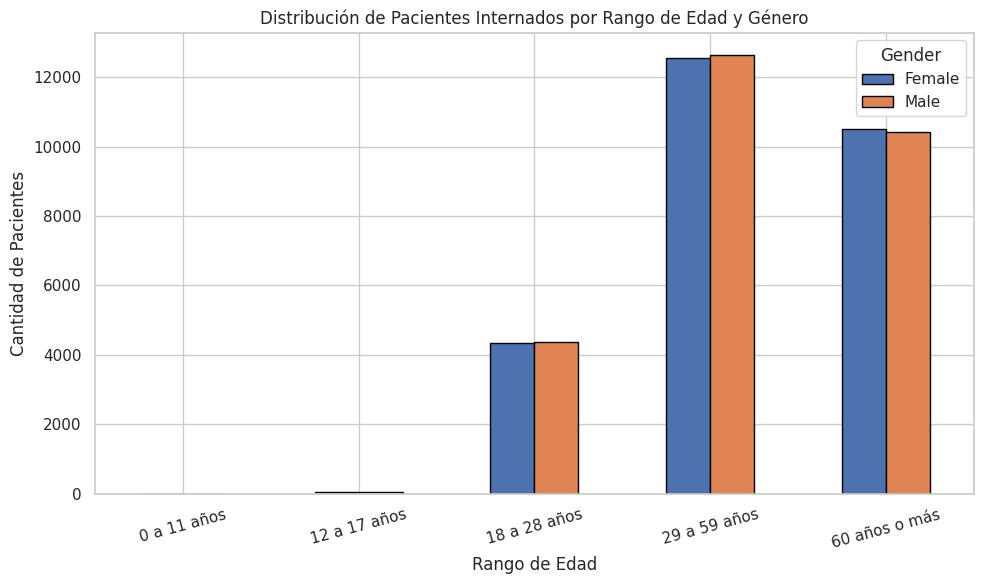

In [141]:
matriz_edad_genero = pd.crosstab(base['Age Range'], base['Gender'])
orden_rangos = ['0 a 11 años', '12 a 17 años', '18 a 28 años', '29 a 59 años', '60 años o más']
matriz_edad_genero = matriz_edad_genero.reindex(orden_rangos)
matriz_edad_genero.plot(kind='bar', figsize=(10, 6), edgecolor='black')
plt.title('Distribución de Pacientes Internados por Rango de Edad y Género')
plt.xlabel('Rango de Edad')
plt.ylabel('Cantidad de Pacientes')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

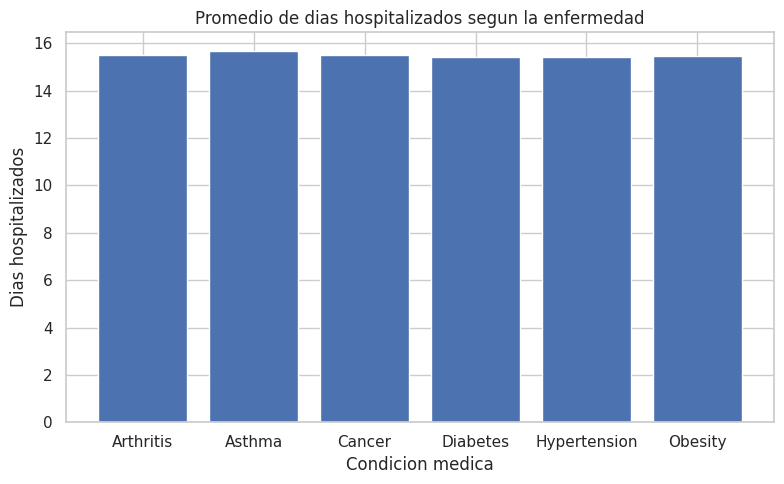

In [142]:
analisis_ordenado = base.groupby('Medical Condition')['Days Hospitalized'].mean()
plt.figure(figsize=(8,5))
plt.bar(analisis_ordenado.index, analisis_ordenado.values)
plt.title("Promedio de dias hospitalizados segun la enfermedad")
plt.xlabel("Condicion medica")
plt.ylabel("Dias hospitalizados")
plt.tight_layout()
plt.show()

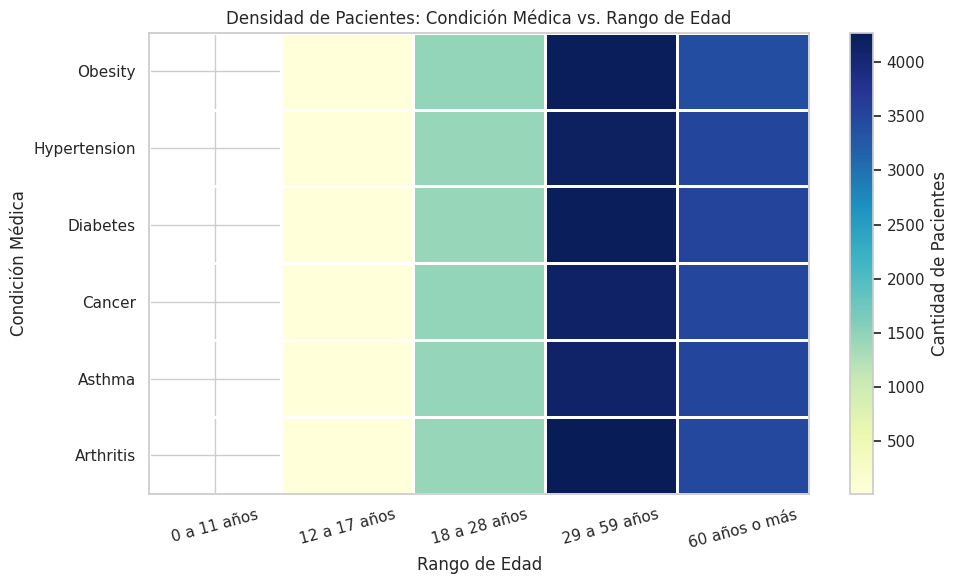

In [143]:
matriz_cruce = pd.crosstab(base['Medical Condition'], base['Age Range'])
orden_rangos = ['0 a 11 años', '12 a 17 años', '18 a 28 años', '29 a 59 años', '60 años o más']
matriz_cruce = matriz_cruce.reindex(columns=orden_rangos)
plt.figure(figsize=(10, 6))
plt.pcolormesh(matriz_cruce.columns, matriz_cruce.index, matriz_cruce, cmap="YlGnBu", edgecolor='white')
plt.colorbar(label='Cantidad de Pacientes')
plt.title('Densidad de Pacientes: Condición Médica vs. Rango de Edad')
plt.xlabel('Rango de Edad')
plt.ylabel('Condición Médica')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

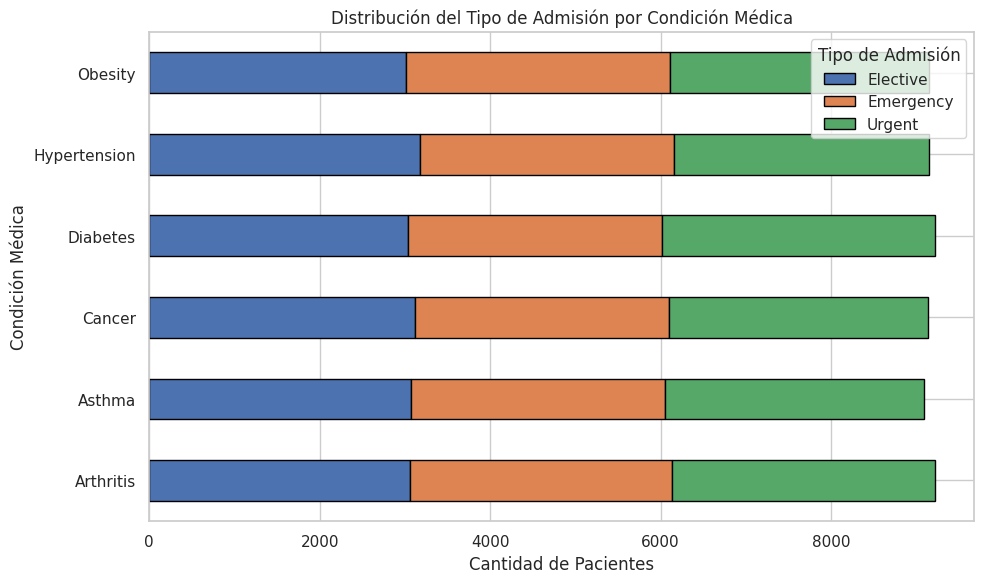

In [144]:
matriz_admision = pd.crosstab(base['Medical Condition'], base['Admission Type'])
plt.figure(figsize=(10, 6))
matriz_admision.plot(kind='barh', stacked=True, ax=plt.gca(), edgecolor='black')
plt.title('Distribución del Tipo de Admisión por Condición Médica')
plt.xlabel('Cantidad de Pacientes')
plt.ylabel('Condición Médica')
plt.legend(title='Tipo de Admisión')
plt.tight_layout()
plt.show()

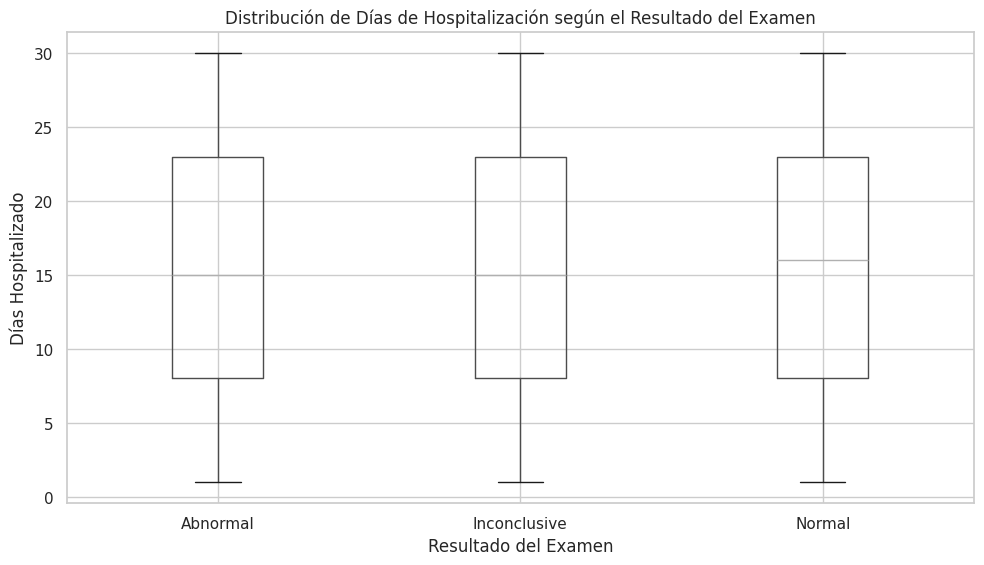

In [145]:
plt.figure(figsize=(10, 6))
base.boxplot(column='Days Hospitalized', by='Test Results', ax=plt.gca())
plt.title('Distribución de Días de Hospitalización según el Resultado del Examen')
plt.suptitle('')
plt.xlabel('Resultado del Examen')
plt.ylabel('Días Hospitalizado')
plt.tight_layout()
plt.show()